In [31]:
import torch
import torch.nn as nn
from models.multimodalAttention import MultiModalAttentionRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data.datamodule import DataModuleTemporal
import torchvision
import tqdm

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalAttentionRegressor()
checkpoint = torch.load("checkpoints/ATT&DAR_MULTIMODAL_2025-05-22_13-15-01.pt",weights_only=False)["model_state_dict"]
model.load_state_dict(checkpoint, strict=False)
model.to(device)

Using cache found in /users/eleves-b/2023/keyvan.attarian/.cache/torch/hub/facebookresearch_dinov2_main


shape of image encoder:  768
shape of text encoder:  768
shape of channel embedding:  8


MultiModalAttentionRegressor(
  (image_encoder): DinoV2Finetune(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features

In [18]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
datamodule = DataModuleTemporal(
    dataset_path="dataset/",
    train_transform=transform,
    test_transform=transform,
    batch_size=256,
    num_workers=8,
    taille_val=0.2,
)
val_loader = datamodule.val_dataloader()

dataset//train_val.csv
Entrainement temporalisé
Pourcentage des données utilisées pour la validation : 19.51%
dataset//train_val.csv
Utilisation des indices fournis pour créer les ensembles d'entraînement et de validation.


In [21]:
loss_fn = nn.MSELoss()

In [26]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [ ]:
epoch_val_loss = 0
num_samples_val = 0
model.eval()
all_targets = []
all_preds = []
all_losses = []
all_channels = []

for _, batch in enumerate(tqdm.tqdm(val_loader, desc="Validating")):
    batch["image"] = batch["image"].to(device)
    batch["target"] = batch["target"].to(device).squeeze()
    batch["channel"] = batch["channel"].to(device)
    batch["year"] = batch["year"].to(device)
    with torch.no_grad():
        preds = model(batch).squeeze()
    loss = nn.functional.mse_loss(preds, batch["target"], reduction='none')  # shape: (batch_size,)
    # Collect for scatter plot
    all_targets.append(batch["target"].detach().cpu().numpy())
    all_preds.append(preds.detach().cpu().numpy())
    all_losses.append(loss.detach().cpu().numpy())
    all_channels.append(batch["channel"].detach().cpu().numpy())


# After validation loop, scatter predictions vs target
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
all_losses = np.concatenate(all_losses)
all_channels = np.concatenate(all_channels)
print(all_losses.mean())

Validating: 100%|██████████| 12/12 [00:17<00:00,  1.44s/it]

3.6019938


In [49]:
channel_embeddings = model.channel_embedding
import sklearn.decomposition

# Get the embedding weights as a numpy array
emb_weights = channel_embeddings.weight.detach().cpu().numpy()

# Fit PCA to reduce to 2 components
pca = sklearn.decomposition.PCA(n_components=1)
emb_pca = pca.fit_transform(emb_weights)

print("PCA shape:", emb_pca.shape)

PCA shape: (46, 1)


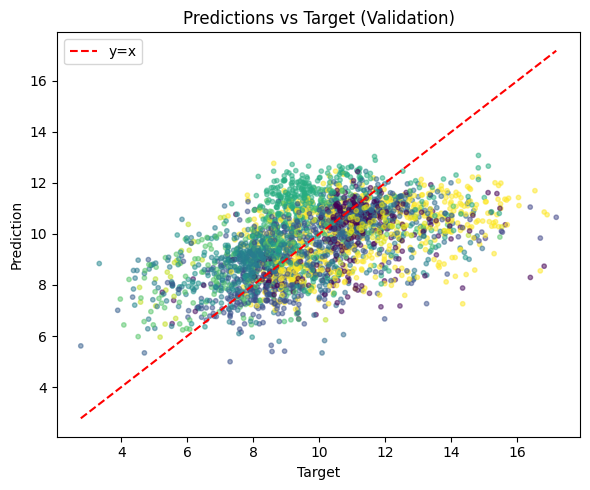

In [62]:

# Plot 1: Predictions vs Target
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_preds, alpha=0.5,c=all_channels_pca, cmap='viridis', s=10)
plt.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--', label='y=x')
plt.legend()
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Predictions vs Target (Validation)")
plt.tight_layout()
plt.show()
plt.close()

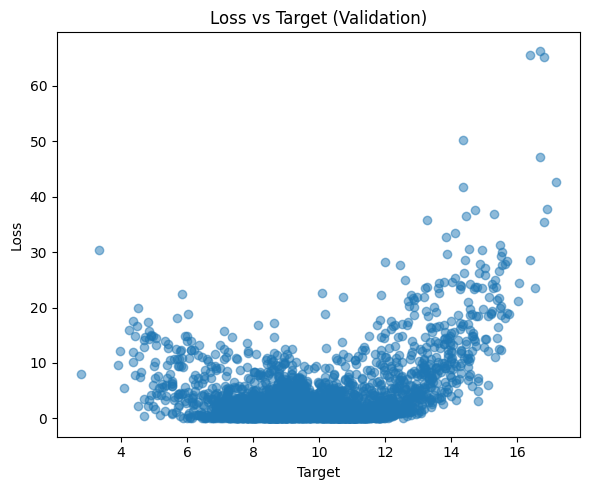

In [38]:
# Plot 2: Loss vs Target
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_losses, alpha=0.5)
plt.xlabel("Target")
plt.ylabel("Loss")
plt.title("Loss vs Target (Validation)")
plt.tight_layout()
plt.show()
plt.close()

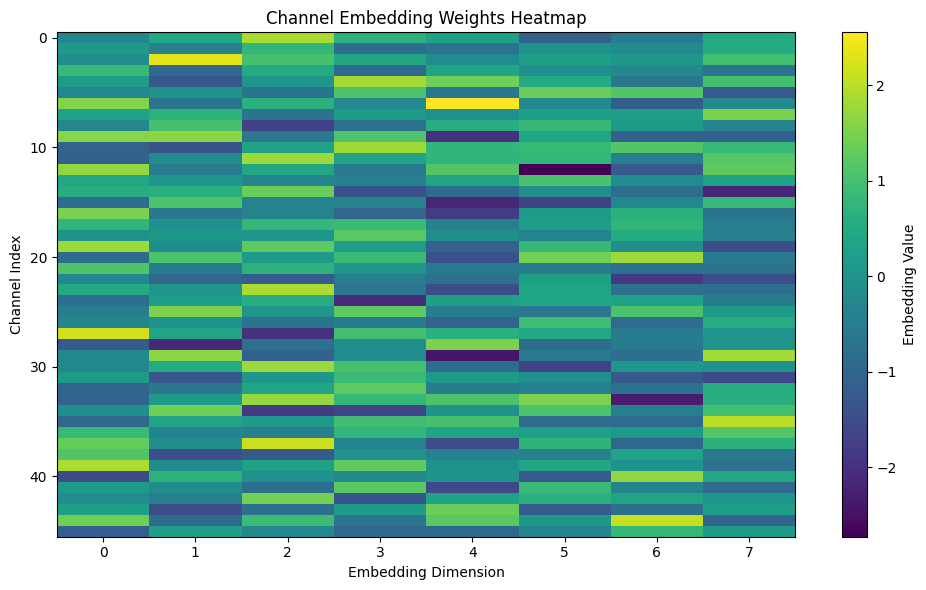

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(emb_weights, aspect='auto', cmap='viridis')
plt.colorbar(label='Embedding Value')
plt.xlabel('Embedding Dimension')
plt.ylabel('Channel Index')
plt.title('Channel Embedding Weights Heatmap')
plt.tight_layout()
plt.show()
plt.close()

In [54]:
# Replace channel id in all_channels by its corresponding PCA embedding value
# all_channels shape: (N, 1), emb_pca shape: (46, 1)
all_channels_pca = emb_pca[all_channels.flatten()].flatten()
all_channels_pca

array([ 0.80941087,  0.22857815, -2.310461  , ...,  0.509148  ,
       -0.21539094,  0.9028037 ], dtype=float32)

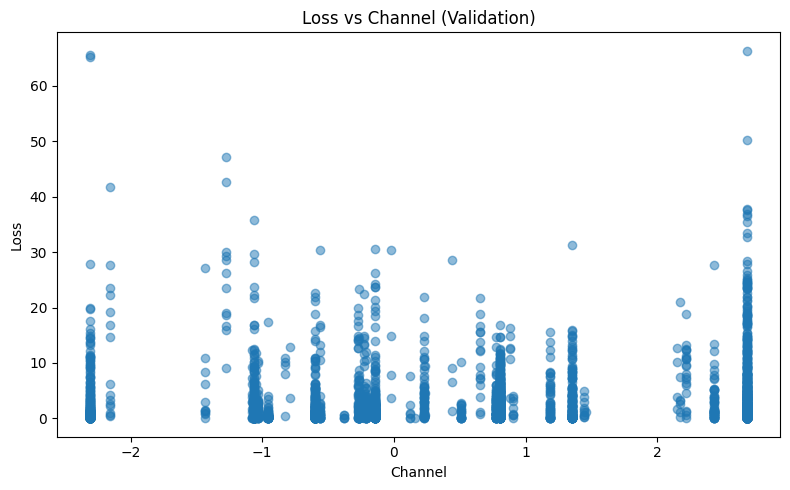

In [55]:
# Concatenate all_channels into a flat numpy array

plt.figure(figsize=(8, 5))
plt.scatter(all_channels_pca, all_losses, alpha=0.5)
plt.xlabel("Channel")
plt.ylabel("Loss")
plt.title("Loss vs Channel (Validation)")
plt.tight_layout()
plt.show()
plt.close()

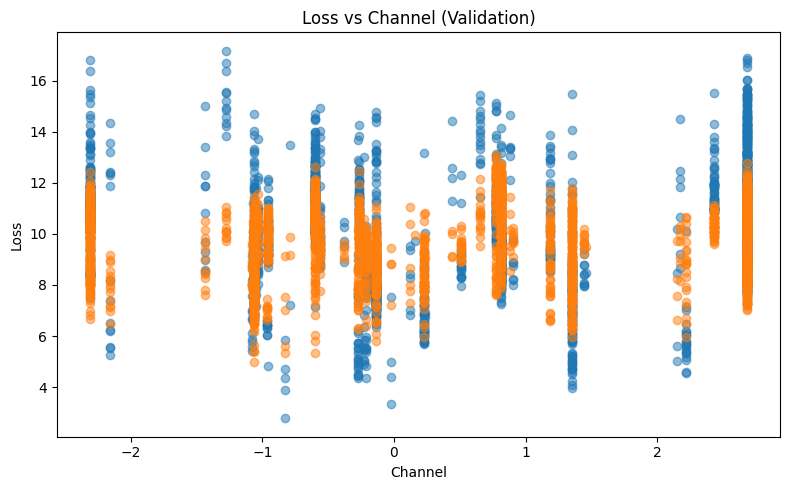

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(all_channels_pca, all_targets, alpha=0.5)
plt.scatter(all_channels_pca, all_preds, alpha=0.5)
plt.xlabel("Channel")
plt.ylabel("Loss")
plt.title("Loss vs Channel (Validation)")
plt.tight_layout()
plt.show()
plt.close()